# Question 3
### 3.1 Creating the Corpus Dataframe


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# locate corpus files
corpus_dir = '../data/corpus'
files = sorted([f for f in os.listdir(corpus_dir) if f.endswith('.txt')])

# load each file
records = []
for fname in files:
    with open(os.path.join(corpus_dir, fname), encoding='utf-8') as f:
        content = f.read()
    records.append({
        'article_id': len(records) + 1,
        'filename':   fname,
        'content':    content,
    })

# build dataframe
corpus = pd.DataFrame(records)
corpus['word_count'] = corpus['content'].str.split().str.len()
corpus['char_count'] = corpus['content'].str.len()

# overview
print("Corpus shape:", corpus.shape)
print(corpus[['article_id', 'filename', 'word_count', 'char_count']])

Corpus shape: (5, 5)
   article_id        filename  word_count  char_count
0           1  research_1.txt        5602       38160
1           2  research_2.txt        2416       16104
2           3  research_3.txt        3828       26154
3           4  research_4.txt        5922       38950
4           5  research_5.txt        4027       26831


In [2]:
# Display the content of the articles
pd.set_option('display.max_colwidth', 150)
print(corpus[['article_id', 'filename', 'content']])

   article_id        filename  \
0           1  research_1.txt   
1           2  research_2.txt   
2           3  research_3.txt   
3           4  research_4.txt   
4           5  research_5.txt   

                                                                                                                                                 content  
0  The purposes of this article are to position mixed methods research\n(mixed research is a synonym) as the natural complement to traditional qualit...  
1  Now I see it, now I don’t:\nresearcher’s position and\nreflexivity in qualitative\nresearch\nRoni Berger\nAdelphi University, USA\nAbstract\nThis ...  
2  DEVELOPMENTAL RESEARCH: STUDIES OF\nINSTRUCTIONAL DESIGN AND DEVELOPMENT\nRita C. Richey\nWayne State University\nJames D. Klein\nArizona State Un...  
3  Abstract\nCronbach’s alpha is a statistic commonly quoted by authors to demonstrate that tests and scales that have been constructed or adopted fo...  
4  Denzin’s Paradigm Shift

## 3.2 Preprocessing (State-of-the-Art Denoising)

In [3]:
import spacy
import re

# load spaCy English model
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])

def spacy_clean(text):
    # strip URLs, emails, DOIs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'10\.\d{4,9}/\S+', ' ', text)

    # remove standalone numbers (page numbers, section numbers)
    text = re.sub(r'^\s*\d+\s*$', ' ', text, flags=re.MULTILINE)

    # run spaCy pipeline
    doc = nlp(text)

    # keep alphabetic tokens, drop stopwords + very short tokens, lemmatize
    tokens = [
        t.lemma_.lower()
        for t in doc
        if t.is_alpha and not t.is_stop and len(t.text) > 2
    ]
    return ' '.join(tokens)

# apply to each article
corpus['clean'] = corpus['content'].apply(spacy_clean)
corpus['clean_word_count'] = corpus['clean'].str.split().str.len()

# compare before/after
print(corpus[['article_id', 'filename', 'word_count', 'clean_word_count']])

   article_id        filename  word_count  clean_word_count
0           1  research_1.txt        5602              2924
1           2  research_2.txt        2416              1191
2           3  research_3.txt        3828              1984
3           4  research_4.txt        5922              2980
4           5  research_5.txt        4027              2102


#### Preprocessing Results

Using spaCy,  URLs, emails, DOIs, standalone numbers, stopwords, and 
short tokens were removed. Each remaining token was lemmatized to its base form.

The word count dropped by roughly half for every article, confirming the denoising 
step removed substantial noise while preserving the meaningful content words.

This cleaner text is essential for summarization because without it, the models would 
waste attention on filler words and formatting artifacts.

In [4]:
# before/after example
print("BEFORE (raw):")
print(corpus['content'].iloc[0][:400])
print("\nAFTER (denoised):")
print(corpus['clean'].iloc[0][:400])

BEFORE (raw):
The purposes of this article are to position mixed methods research
(mixed research is a synonym) as the natural complement to traditional qualitative and quantitative research, to present pragmatism
as offering an attractive philosophical partner for mixed methods research, and to provide a framework for designing and conducting
mixed methods research. In doing this, we briefly review the paradig

AFTER (denoised):
purpose article position mixed method research mixed research synonym natural complement traditional qualitative quantitative research present pragmatism offer attractive philosophical partner mixed method research provide framework design conduct mixed method research briefly review paradigm war incompatibility thesis commonality quantitative qualitative research explain tenet pragmatism explain 


### 3.3 Summarize first article  using Extractive  TextRank technique

In [5]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
from sumy.nlp.stemmers import Stemmer
from sumy.utils import get_stop_words

# extract first article (raw text — summarizer needs whole sentences)
article_id = 1
article_text = corpus.loc[corpus['article_id'] == article_id, 'content'].iloc[0]

# TextRank extractive summarizer
parser = PlaintextParser.from_string(article_text, Tokenizer('english'))
summarizer = TextRankSummarizer(Stemmer('english'))
summarizer.stop_words = get_stop_words('english')

# 5-sentence summary
summary_sentences = summarizer(parser.document, sentences_count=5)

print("=== Extractive Summary (TextRank) — research_1.txt ===\n")
for i, s in enumerate(summary_sentences, 1):
    print(f"{i}. {s}\n")

=== Extractive Summary (TextRank) — research_1.txt ===

1. The purposes of this article are to position mixed methods research (mixed research is a synonym) as the natural complement to traditional qualitative and quantitative research, to present pragmatism as offering an attractive philosophical partner for mixed methods research, and to provide a framework for designing and conducting mixed methods research.

2. In doing this, we briefly review the paradigm “wars” and incompatibility thesis, we show some commonalities between quantitative and qualitative research, we explain the tenets of pragmatism, we explain the fundamental principle of mixed research and how to apply it, we provide specific sets of designs for the two major types of mixed methods research (mixed-model designs and mixed-method designs), and, finally, we explain mixed methods research as following (recursively) an eight-step process.

3. Our purpose in writing this article is to present mixed methods research as t

## visualisations

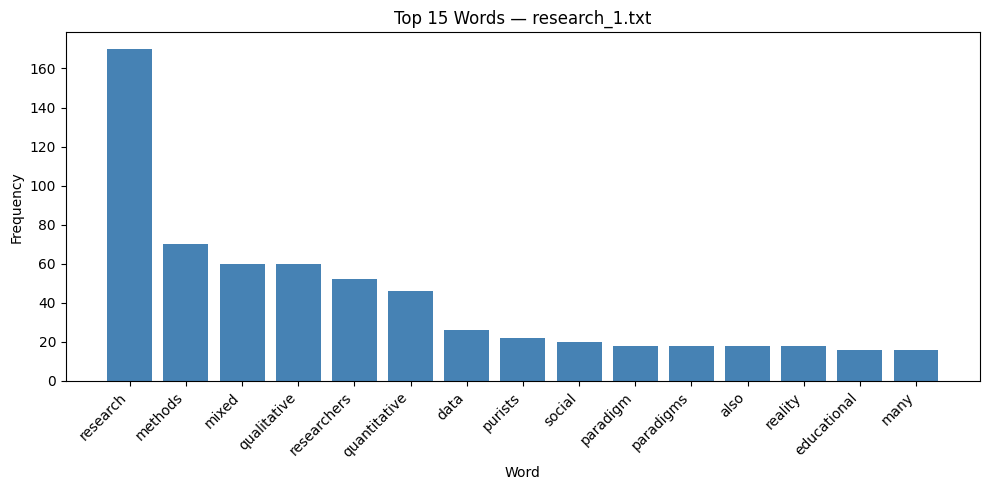

In [6]:
import re
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords

# clean text: lowercase, alphabetic only
raw = re.sub(r'\n+', ' ', article_text)
stop = set(stopwords.words('english'))

words = [
    w.lower() for w in re.findall(r'\b[a-z]{4,}\b', raw.lower())
    if w.lower() not in stop
]

# top 15 most frequent words
top_words = Counter(words).most_common(15)
labels = [w for w, _ in top_words]
counts = [c for _, c in top_words]

# plot
plt.figure(figsize=(10, 5))
plt.bar(labels, counts, color='steelblue')
plt.title("Top 15 Words — research_1.txt")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/q3_extractive_scores.png', dpi=120)
plt.show()

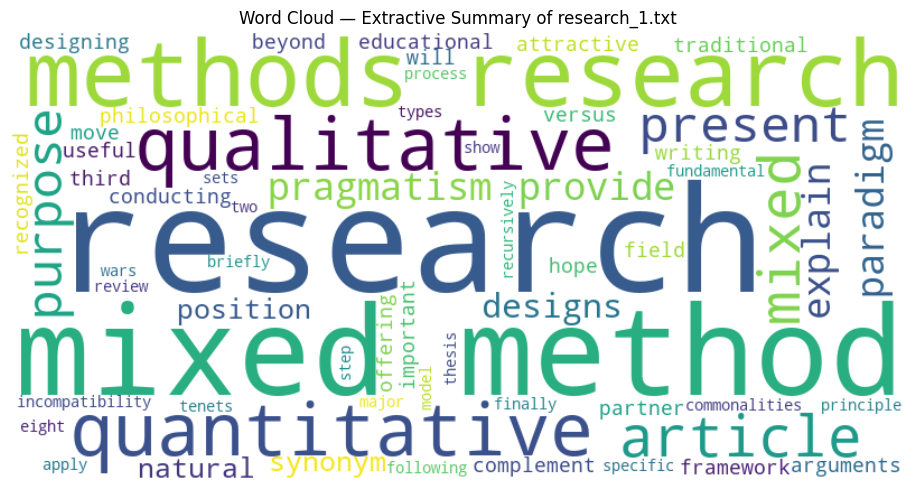

In [7]:
from wordcloud import WordCloud

# word cloud of the extracted summary
summary_text = ' '.join(str(s) for s in summary_sentences)
wc = WordCloud(width=800, height=400, background_color='white').generate(summary_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — Extractive Summary of research_1.txt")
plt.tight_layout()
plt.savefig('../outputs/q3_extractive_wordcloud.png', dpi=120)
plt.show()

#### Visualizations for research_1.txt comment

**Top 15 Words Chart:**
Shows the most common words in the paper. The biggest bars reveal what the 
paper talks about most.

**Word Cloud:**
Same idea, but visual. Bigger words = more frequent. Important terms like 
"mixed," "research," and "methods" stand out.

**Why this matters:**
Both plots confirm the TextRank summary kept the paper's main topics. If random 
sentences were picked, the visuals would look scattered instead of focused.

## 3.4 Summarization of Remaining Articles using LSA technique

In [9]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer
from sumy.nlp.stemmers import Stemmer
from sumy.utils import get_stop_words

# LSA summarizer setup
def lsa_summarize(text, n_sentences=4):
    parser = PlaintextParser.from_string(text, Tokenizer('english'))
    summarizer = LsaSummarizer(Stemmer('english'))
    summarizer.stop_words = get_stop_words('english')
    sentences = summarizer(parser.document, sentences_count=n_sentences)
    return ' '.join(str(s) for s in sentences)

# apply to articles 2-5
remaining = corpus[corpus['article_id'] > 1].copy()
remaining['lsa_summary'] = remaining['content'].apply(lsa_summarize)

# print results
for _, row in remaining.iterrows():
    print(f"\n=== {row['filename']} ===")
    print(row['lsa_summary'])


=== research_2.txt ===
Parallel to the expectation that clinical practitioners pay attention to the impact of their own history and issues on their understanding of and reactions to the client (conceptualized in psychodynamic language as counter transference), reflexivity is the self-appraisal in research. Finally, the worldview and background of the researcher affects the way in which he or she constructs the world, uses language, poses questions, and chooses the lens for filtering the information gathered from participants and making meaning of it, and thus may shape the findings and conclusions of the study (Kacen and Chaitin, 2006). At that time, I had had my share of encounters with unfriendly personnel of immigration services, coping with the hardships of reestablishing my credentials as well as my financial and social status; learning to live in a language, which was not my own; and coming to terms with my dual identity. Furthermore, I was guided by my own experience to explore

#### Summarization Results

LSA was used to summarize research_2 through research_5, generating 4-sentence 
summaries for each. TextRank was used for research_1 in the previous step.

**Themes captured in each summary:**

- **research_2:** Reflexivity in qualitative research - the researcher's own 
  background and experiences shape the study's findings.

- **research_3:** Instructional design and development - how systematic design 
  procedures relate to educational research.

- **research_4:** Cronbach's alpha and reliability - concerns about how alpha 
  is used and reported in science education journals.

- **research_5:** Triangulation in qualitative research - using multiple methods 
  to reduce bias and strengthen validity.

  Lastly, all five papers deal with research methodology, including how to design, conduct, and 
evaluate research properly.

In [13]:
# add summary column: TextRank for article 1, LSA for articles 2-5
corpus['summary'] = None
corpus.loc[0, 'summary'] = ' '.join(str(s) for s in summary_sentences)

for _, row in remaining.iterrows():
    idx = corpus[corpus['filename'] == row['filename']].index[0]
    corpus.loc[idx, 'summary'] = row['lsa_summary']

print(corpus[['article_id', 'filename']])
print("\nSummaries stored.")

   article_id        filename
0           1  research_1.txt
1           2  research_2.txt
2           3  research_3.txt
3           4  research_4.txt
4           5  research_5.txt

Summaries stored.


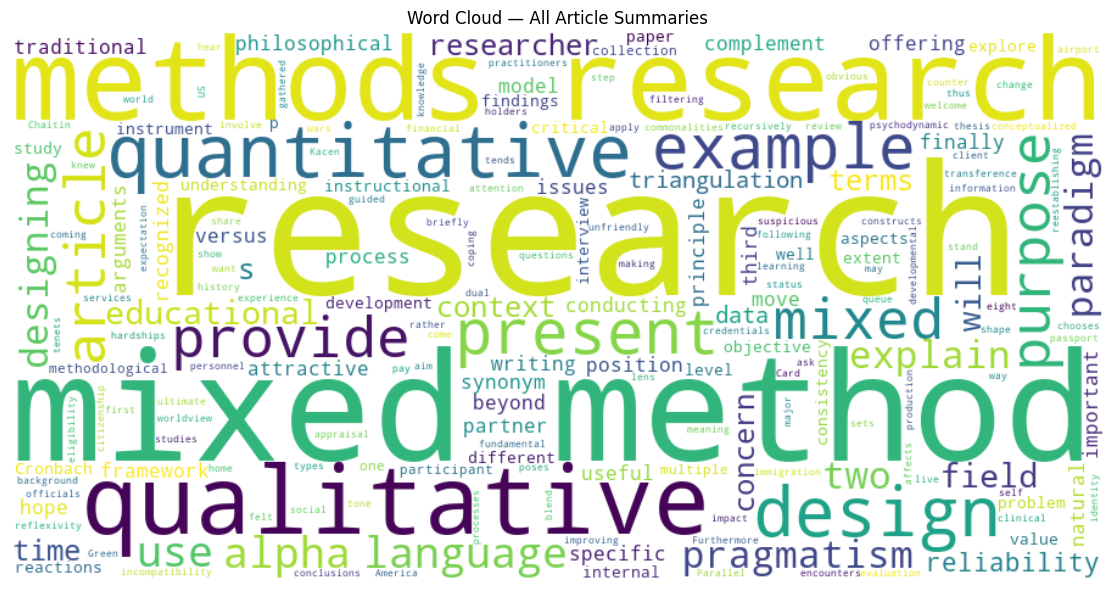

In [14]:
from wordcloud import WordCloud

# combine all summaries
all_summaries = ' '.join(corpus['summary'].dropna().tolist())

wc = WordCloud(width=900, height=450, background_color='white').generate(all_summaries)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — All Article Summaries")
plt.tight_layout()
plt.savefig('../outputs/q3_abstractive_wordcloud.png', dpi=120)
plt.show()

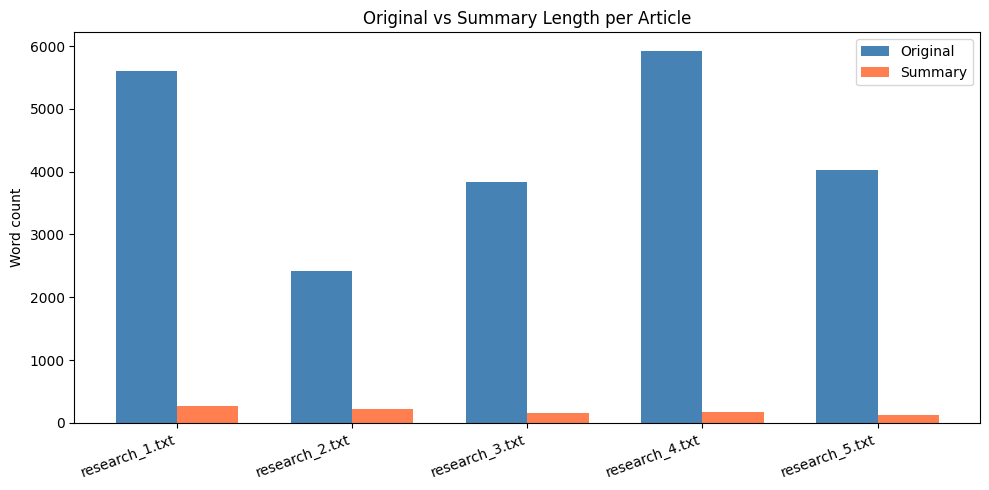

In [15]:
# compare original vs summary length per article
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(corpus))
width = 0.35

original_lengths = corpus['word_count']
summary_lengths = corpus['summary'].str.split().str.len()

ax.bar(x - width/2, original_lengths, width, label='Original', color='steelblue')
ax.bar(x + width/2, summary_lengths, width, label='Summary', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(corpus['filename'], rotation=20, ha='right')
ax.set_ylabel('Word count')
ax.set_title('Original vs Summary Length per Article')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/q3_summary_lengths.png', dpi=120)
plt.show()

#### Visualizing All Summaries Comment

**Word Cloud:**
Shows the most common words across all summaries. Big words like "research," "methods," 
"mixed," and "qualitative" confirm the summaries kept the technical vocabulary from 
each paper.

**Original vs Summary Length:**
Shows word count before and after summarization. Every article dropped from thousands 
of words to just a few dozen - huge compression.

**Combined insight:**
Both visuals prove the same thing: the summaries are short but still capture the 
main ideas. The word cloud shows meaning was preserved, and the bar chart shows 
length was reduced.